<a href="https://colab.research.google.com/github/Moulicodes/car-price-prediction/blob/main/car_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df = pd.read_csv("car_price_prediction.csv")
backup_df = df.copy()

In [163]:
df.shape

(19237, 18)

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [165]:
df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)
df.drop(columns =  ['ID'], inplace = True)

In [166]:
df.sample(3)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19068,17415,1185,hyundai,h1,2009,minivan,yes,diesel,2.5,75988 km,4.0,automatic,front,04-may,left wheel,black,4
18273,1568,382,ford,fusion,2015,sedan,yes,hybrid,2,107166 km,4.0,automatic,front,04-may,left wheel,white,0
17520,10976,765,hyundai,sonata,2015,sedan,yes,lpg,2,385876 km,4.0,automatic,front,04-may,left wheel,white,4


In [167]:
df['Levy'] = df['Levy'].apply(lambda x: int(x) if x != '-' else 0)
df['Engine volume_type'] = df['Engine volume'].apply(lambda x: x.split()[1] if len(x.split()) == 2 else 'normal')
df['Engine volume'] = df['Engine volume'].apply(lambda x: float(x.split()[0]))
df['Mileage'] = df['Mileage'].apply(lambda x: int(x.split()[0]))
df['Cylinders'] = df['Cylinders'].astype(int)

In [168]:
df.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,19237.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000
mean,1.855593e+04,632.528669,2010.912824,2.307990,1.532236e+06,4.582991,6.582627
std,1.905813e+05,567.721688,5.668673,0.877805,4.840387e+07,1.199933,4.320168
min,1.000000e+00,0.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,5.331000e+03,0.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,1.317200e+04,642.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,2.207500e+04,917.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


Outlier Detection

1. Price

In [169]:
df['Price'].describe()

,Price
count,1.923700e+04
mean,1.855593e+04
std,1.905813e+05
min,1.000000e+00
25%,5.331000e+03
50%,1.317200e+04
75%,2.207500e+04
max,2.630750e+07


In [170]:
df['Price'].quantile(0.9), df['Price'].quantile(0.99), df['Price'].quantile(0.999)

(np.float64(38609.0), np.float64(84675.0), np.float64(171375.6200000134))

<Axes: ylabel='Price'>

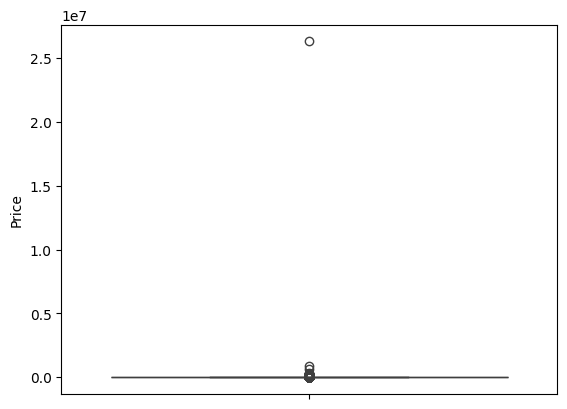

In [171]:
sns.boxplot(df['Price'])

In [172]:
df = df[df['Price'] < 2.5e+07]

<Axes: ylabel='Price'>

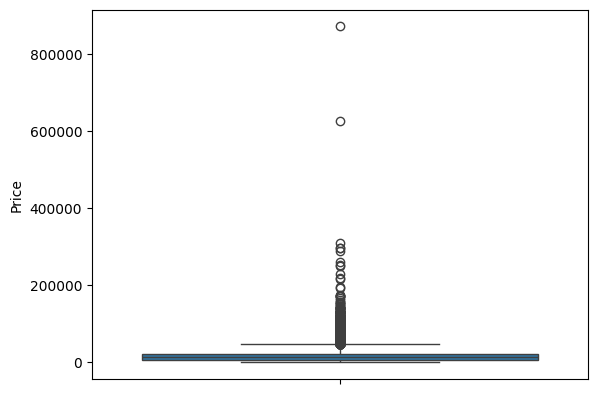

In [173]:
sns.boxplot(df['Price'])

In [174]:
df = df[(df['Price'] >= 1000) & (df['Price'] <= 400000)]

In [175]:
df.shape

(16660, 18)

<Axes: ylabel='Price'>

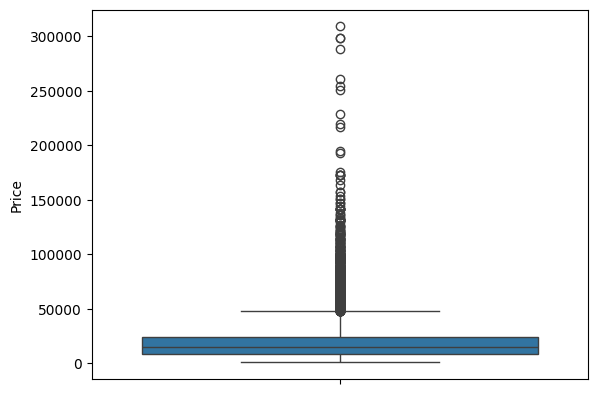

In [176]:
sns.boxplot(df['Price'])

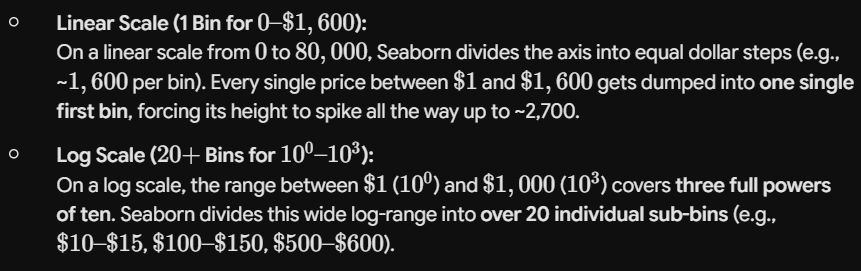

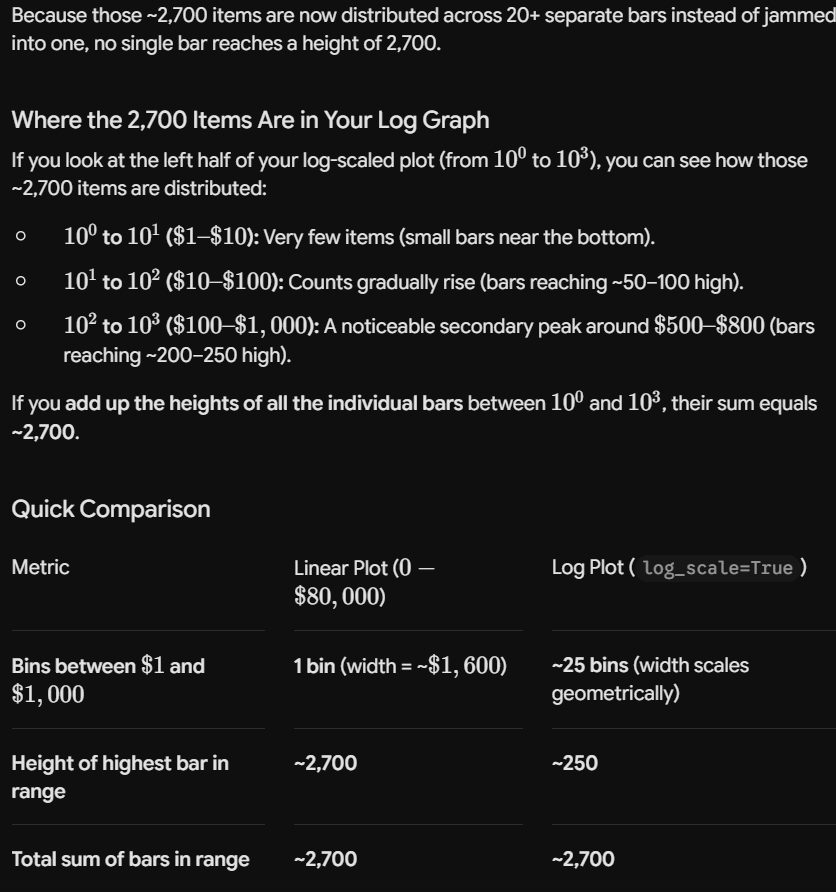

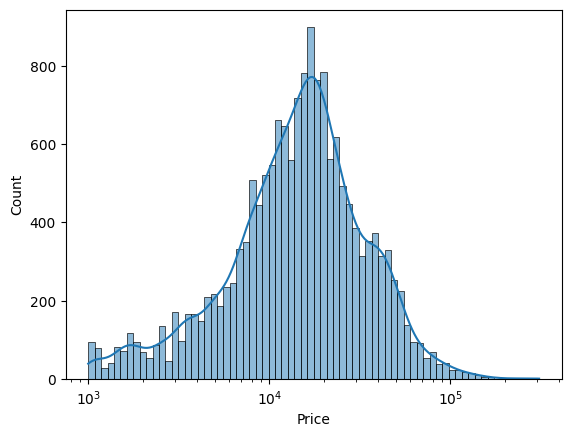

In [177]:
sns.histplot(df['Price'], log_scale = True, kde = True)
plt.show()

2. Engine Volume and Prod. year

Levy depends heavily on engine volume and the age of the vehicle. So it would make sense to handle the outliers in engine volume and prod. year before moving on to levy.

In [178]:
df['Engine volume'].describe()

,Engine volume
count,16660.000000
mean,2.264610
std,0.844683
min,0.000000
25%,1.800000
50%,2.000000
75%,2.500000
max,20.000000


<Axes: ylabel='Engine volume'>

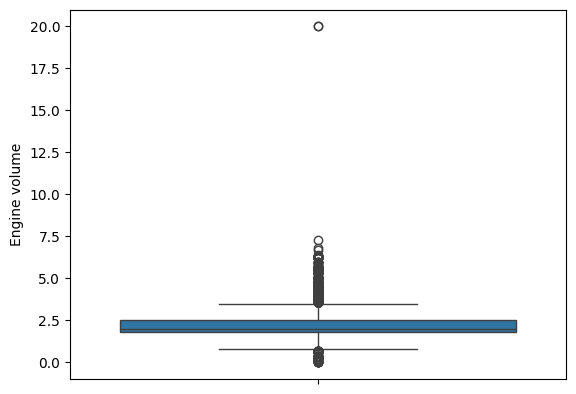

In [179]:
sns.boxplot(df['Engine volume'])

In [180]:
df = df[(df['Engine volume'] > 0.5) & (df['Engine volume'] < 9.0)]

<Axes: ylabel='Engine volume'>

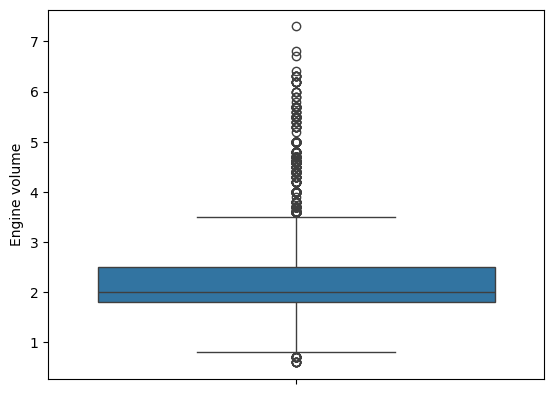

In [181]:
sns.boxplot(df['Engine volume'])

In [182]:
df['Prod. year'].describe()

,Prod. year
count,16630.000000
mean,2010.753818
std,5.756187
min,1943.000000
25%,2009.000000
50%,2012.000000
75%,2015.000000
max,2020.000000


<Axes: ylabel='Prod. year'>

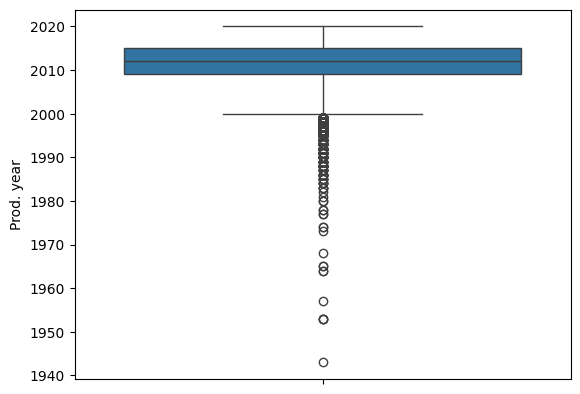

In [183]:
sns.boxplot(df['Prod. year'])

In [184]:
df = df[df['Prod. year'] >= 1970]

<Axes: ylabel='Prod. year'>

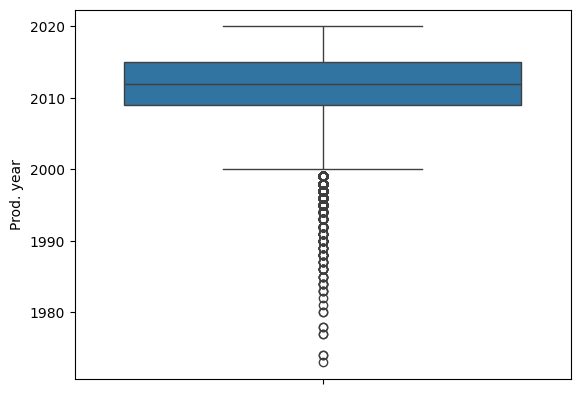

In [185]:
sns.boxplot(df['Prod. year'])

In [186]:
df[(df['Prod. year'] >= 1970) & (df['Prod. year'] <= 1990)].sample(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Engine volume_type
16036,2800,0,vaz,2103 03,1981,sedan,yes,petrol,1.3,55000,4,manual,front,04-may,left wheel,orange,0,normal
12372,6272,0,opel,astra g,1988,universal,no,petrol,1.2,189000,4,manual,front,04-may,left wheel,blue,4,normal
13613,1400,0,mercedes-benz,190,1990,sedan,no,petrol,2.0,237065,4,manual,front,04-may,left wheel,silver,0,normal
14602,3136,0,volkswagen,jetta,1990,sedan,no,cng,1.8,500,4,manual,front,04-may,left wheel,blue,0,normal
14297,31361,0,suzuki,samurai,1982,jeep,no,petrol,0.8,29500,3,manual,4x4,02-mar,left wheel,blue,1,normal
144,4300,0,mercedes-benz,208,1985,universal,no,diesel,2.5,1111111,4,manual,rear,04-may,left wheel,black,1,normal
3109,1000,0,vaz,2121 (niva),1983,sedan,no,petrol,1.3,0,4,manual,4x4,02-mar,left wheel,beige,0,normal
9540,10036,0,uaz,31514,1987,jeep,yes,petrol,2.0,0,4,manual,4x4,04-may,left wheel,green,4,normal
17281,5000,0,vaz,2106,1977,sedan,no,petrol,1.6,37500,4,manual,rear,04-may,left wheel,sky blue,0,normal
14119,1568,0,vaz,2109,1990,hatchback,no,petrol,1.6,350000,4,manual,front,04-may,left wheel,grey,11,normal


In [187]:
df.shape

(16620, 18)

3. Levy - usually, larger the engine vol and older the car, higher the levy

In [188]:
df['Levy'].describe()

,Levy
count,16620.000000
mean,600.083755
std,555.713708
min,0.000000
25%,0.000000
50%,640.000000
75%,891.000000
max,11714.000000


<Axes: ylabel='Levy'>

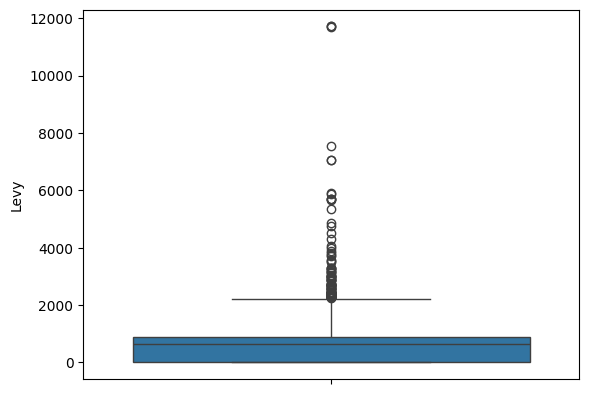

In [189]:
sns.boxplot(df['Levy'])

In [190]:
df['Levy'].quantile(0.9), df['Levy'].quantile(0.99), df['Levy'].quantile(0.999)

(np.float64(1236.0), np.float64(1995.0), np.float64(4143.106000000276))

In [191]:
df[df['Levy'] > 4000]
#mostly unrealistic levy values as any value more than 4000 would require a massive commercial truck engine 8.0L+V12 or extreme luxury supercars 6.5L+ Lamborghinis/Ferrari

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Engine volume_type
115,11917,11714,mercedes-benz,e 500 amg,2003,sedan,yes,petrol,5.0,150000,12,tiptronic,rear,04-may,right-hand drive,white,12,normal
1571,7840,4508,bmw,320 m,2001,universal,no,petrol,1.9,183000,4,tiptronic,rear,04-may,right-hand drive,black,6,normal
2159,10349,7058,subaru,legacy,2005,sedan,yes,petrol,3.0,147000,6,tiptronic,4x4,04-may,right-hand drive,black,6,normal
2323,3150,5679,toyota,estima,1997,minivan,no,petrol,2.4,230000,4,automatic,4x4,04-may,right-hand drive,silver,2,normal
3639,14113,5332,mercedes-benz,e 300 avantgarde-ltd,2007,universal,yes,petrol,3.0,75000,8,tiptronic,rear,04-may,right-hand drive,white,12,normal
3994,13172,7063,toyota,alphard,2003,minivan,yes,lpg,3.0,190000,6,automatic,4x4,04-may,right-hand drive,golden,8,normal
5367,7840,5877,mercedes-benz,clk 430,2005,cabriolet,no,petrol,7.3,156470,12,automatic,rear,04-may,left wheel,black,12,normal
5529,5645,5908,bmw,520,1999,sedan,no,petrol,2.5,0,6,tiptronic,rear,04-may,right-hand drive,silver,4,normal
8160,12544,5666,toyota,ipsum,2004,minivan,no,petrol,2.4,133000,4,automatic,front,04-may,right-hand drive,white,5,normal
8887,10000,4283,honda,elysion,2007,minivan,no,petrol,2.4,141000,4,automatic,front,04-may,right-hand drive,white,2,normal


In [192]:
df = df[df['Levy'] <= 4000]
levy_gt_price = (df['Levy'] > df['Price'])
df = df[~levy_gt_price]

<Axes: ylabel='Levy'>

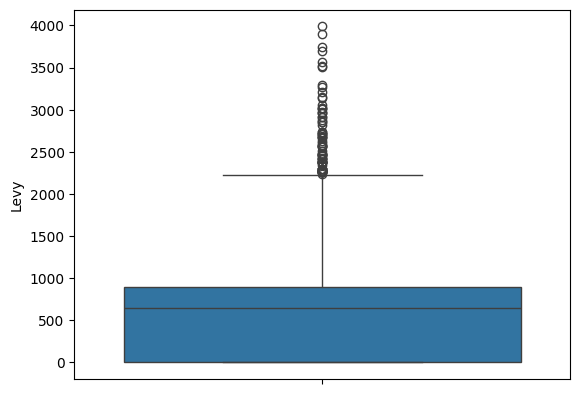

In [193]:
sns.boxplot(df['Levy'])

In [194]:
bad_levy_on_small_engine = (df['Levy'] >= 1500) & (df['Engine volume'] <= 2.0)
df = df[~bad_levy_on_small_engine]
#to drop rows with unrealistically high levies for smaller engine volumes

In [195]:
df.shape

(16444, 18)

4. Mileage

In [196]:
df['Mileage'].describe()

,Mileage
count,1.644400e+04
mean,1.373228e+06
std,4.522041e+07
min,0.000000e+00
25%,6.900750e+04
50%,1.232000e+05
75%,1.810005e+05
max,2.147484e+09


In [197]:
df['Mileage'].quantile(0.9), df['Mileage'].quantile(0.99), df['Mileage'].quantile(0.999)

(np.float64(257050.40000000005),
 np.float64(581801.5199999996),
 np.float64(48665062.405010864))

<Axes: ylabel='Mileage'>

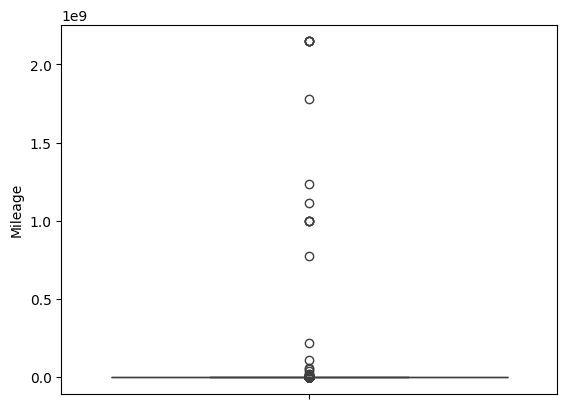

In [198]:
sns.boxplot(df['Mileage'])

In [199]:
df[df['Mileage'] > df['Mileage'].quantile(0.99)].sample(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Engine volume_type
3604,15994,777,toyota,camry,2014,sedan,no,petrol,2.5,1440000,4,automatic,front,04-may,left wheel,silver,0,normal
15156,7840,0,nissan,skyline,2001,sedan,yes,petrol,2.5,840000,6,tiptronic,rear,04-may,right-hand drive,silver,8,normal
1788,8467,639,hyundai,sonata,2014,sedan,yes,lpg,2.0,592541,4,automatic,front,04-may,left wheel,orange,4,normal
18846,14113,0,toyota,prius,2005,hatchback,yes,hybrid,1.5,2696320,4,automatic,front,04-may,left wheel,grey,6,normal
15574,12544,0,bmw,320,2001,sedan,yes,petrol,2.2,1366363,6,tiptronic,rear,04-may,left wheel,silver,8,normal
8824,5018,0,mitsubishi,colt,2002,sedan,no,petrol,1.5,18065445,4,tiptronic,front,04-may,right-hand drive,black,5,normal
15364,10036,0,opel,meriva,2006,universal,no,petrol,1.6,222222222,4,tiptronic,front,04-may,left wheel,silver,6,normal
7429,6272,0,mercedes-benz,vito,1999,minivan,no,diesel,2.3,5555551,4,manual,front,02-mar,left wheel,white,1,normal
16924,10976,765,hyundai,sonata,2015,sedan,yes,lpg,2.0,619021,4,automatic,front,04-may,left wheel,white,4,normal
17807,8467,639,hyundai,sonata,2014,sedan,yes,lpg,2.0,698359,4,automatic,front,04-may,left wheel,orange,4,normal


In [200]:
invalid_bounds = (df['Mileage'] >= 1_000_000) | (df['Mileage'] == 0)

def is_dummy_mileage(val):
  s = str(int(val))

  if (len(set(s)) == 1 and len(s) >= 5):
    return True
  if s in ['12345', '123456']:
    return True
  return False

invalid_patterns = df['Mileage'].apply(is_dummy_mileage)
bad_mileage_mask = invalid_bounds | invalid_patterns


In [201]:
df[bad_mileage_mask]

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Engine volume_type
11,8781,0,ford,transit,1999,microbus,no,cng,4.0,0,8,manual,rear,02-mar,left wheel,blue,0,normal
24,4704,0,opel,vectra,1995,sedan,no,petrol,1.8,0,4,automatic,front,04-may,left wheel,green,4,normal
83,8154,0,honda,cr-v,1998,jeep,no,petrol,2.0,0,4,automatic,4x4,04-may,right-hand drive,white,2,normal
96,18817,0,nissan,patrol,1990,jeep,no,diesel,2.8,333333,4,manual,rear,04-may,left wheel,black,0,turbo
97,4234,0,honda,civic,1997,hatchback,yes,petrol,1.4,0,4,manual,front,02-mar,left wheel,blue,6,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19097,7213,0,land rover,range rover,1997,jeep,yes,diesel,2.5,111111,6,manual,4x4,04-may,left wheel,black,12,turbo
19132,5488,1045,opel,corsa,1999,sedan,yes,petrol,1.2,111111,4,manual,front,04-may,left wheel,black,4,normal
19167,18817,1995,ford,transit,2003,microbus,no,diesel,2.4,2147483647,4,manual,front,02-mar,left wheel,white,2,turbo
19199,3763,0,mercedes-benz,c 180,1995,sedan,no,petrol,1.8,1111111111,5,manual,rear,04-may,right-hand drive,green,2,normal


In [202]:
#Replacing all the bad mileage values with the median mileage value of the corresponding prod. year group
df.loc[bad_mileage_mask, 'Mileage'] = np.nan
df['Mileage'] = df.groupby('Prod. year')['Mileage'].transform(lambda x: x.fillna(x.median()))

#Fallback
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].median())

Why use transform instead of apply:

In [203]:
df.groupby('Prod. year')['Mileage'].transform(lambda x: x.fillna(x.median()))

,Mileage
0,186005.0
1,192000.0
2,200000.0
3,168966.0
4,91901.0
...,...
19231,107800.0
19232,300000.0
19233,161600.0
19234,116365.0


In [204]:
df.groupby('Prod. year')['Mileage'].apply(lambda x: x.fillna(x.median()))

Prod. year       
1973        17634    100000.0
1974        5696       5200.0
            8590       5200.0
1977        457       37500.0
            17281     37500.0
                       ...   
2020        16483      5900.0
            17406      3510.0
            18491      1669.0
            19121     12334.0
            19180      5305.0
Name: Mileage, Length: 16444, dtype: float64

<Axes: ylabel='Mileage'>

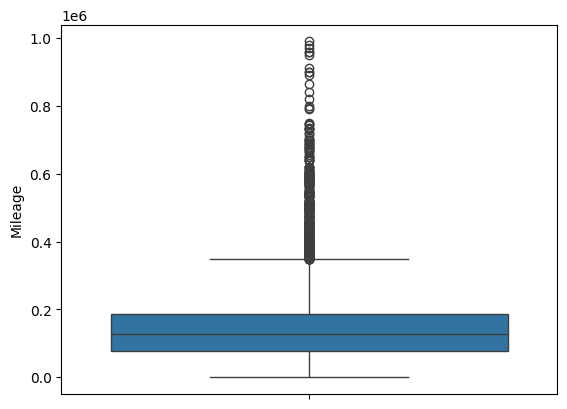

In [205]:
sns.boxplot(df['Mileage'])

5. Cylinders - cylinder count depends heaviy on engine volume. The industry standard is, 0.5L per cylinder with some tolerance

In [206]:
df['Cylinders'].describe()

,Cylinders
count,16444.000000
mean,4.523656
std,1.156590
min,1.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,16.000000


In [207]:
df['Cylinders'].value_counts()

,count
Cylinders,
4,12631
6,2703
8,734
5,152
3,101
2,39
1,33
12,31
10,11


In [208]:
invalid_counts = ~df['Cylinders'].isin([2, 3, 4, 5, 6, 8, 10, 12])
fake_multicyl = (df['Cylinders'] >= 10) & (df['Engine volume'] < 5.0)

df.loc[invalid_counts | fake_multicyl, 'Cylinders'] = np.nan

df['Cylinders'] = df.groupby(['Manufacturer', 'Model'])['Cylinders'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

#Fallback 1: Impute any remaining NaNs using Manufacturer-level Mode
df['Cylinders'] = df.groupby('Manufacturer')['Cylinders'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
#Fallback 2: Mathematical estimation based on Engine Volume
df['Cylinders'] = df['Cylinders'].fillna((df['Engine volume'] / 0.5).round()).astype(int)

In [209]:
df['Cylinders'].value_counts()

,count
Cylinders,
4,12678
6,2724
8,736
5,153
3,102
2,39
10,7
12,5


6. Airbags

In [210]:
df['Airbags'].value_counts()

,count
Airbags,
4,5682
12,3986
0,1678
8,1544
6,1248
2,995
10,827
5,92
16,91


In [211]:
df['Category'].unique()

array(['jeep', 'hatchback', 'sedan', 'microbus', 'goods wagon',
       'universal', 'coupe', 'minivan', 'cabriolet', 'limousine',
       'pickup'], dtype=object)

In [212]:
#Anything more than 2 is unrealistic or extremely rare for the era
df.loc[(df['Prod. year'] < 1995) & (df['Airbags'] > 2), 'Airbags'] = 2

In [213]:
more_airbags_cat = ['sedan', 'microbus', 'minivan', 'universal', 'limousine']
less_airbags_cat = ['hatchback', 'pickup', 'cabriolet', 'goods wagon', 'coupe', 'jeep']

flag1 = (df['Airbags'] > 10) & (df['Category'].isin(less_airbags_cat))
flag2 = (df['Airbags'] > 8) & (df['Prod. year'] < 2008) | (df['Airbags'] > 12)
bad_airbag = flag1 | flag2
df.loc[bad_airbag, 'Airbags'] = np.nan

df['Airbags'] = df.groupby(['Manufacturer', 'Model'])['Airbags'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else np.nan)
df['Airbags'] = df.groupby(['Manufacturer', 'Prod. year'])['Airbags'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else np.nan)
df['Airbags'] = df['Airbags'].fillna(df.groupby('Prod. year')['Airbags'].transform('median'))
df['Airbags'] = df['Airbags'].astype(int)

In [214]:
df['Airbags'].value_counts()

,count
Airbags,
4,5906
12,2568
8,2249
0,2159
6,1390
2,1090
10,743
5,90
7,81


In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 19235
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               16444 non-null  int64  
 1   Levy                16444 non-null  int64  
 2   Manufacturer        16444 non-null  object 
 3   Model               16444 non-null  object 
 4   Prod. year          16444 non-null  int64  
 5   Category            16444 non-null  object 
 6   Leather interior    16444 non-null  object 
 7   Fuel type           16444 non-null  object 
 8   Engine volume       16444 non-null  float64
 9   Mileage             16444 non-null  float64
 10  Cylinders           16444 non-null  int64  
 11  Gear box type       16444 non-null  object 
 12  Drive wheels        16444 non-null  object 
 13  Doors               16444 non-null  object 
 14  Wheel               16444 non-null  object 
 15  Color               16444 non-null  object 
 16  Airbags  

Model Training:

Target Encoding (also known as Mean Encoding) is a technique for converting categorical variables into numerical values by replacing each category with the average target value of the rows belonging to that category.

It is ideal for high-cardinality features (like Model or City) because it creates only one single new numerical column, preventing the massive column expansion caused by One-Hot Encoding.

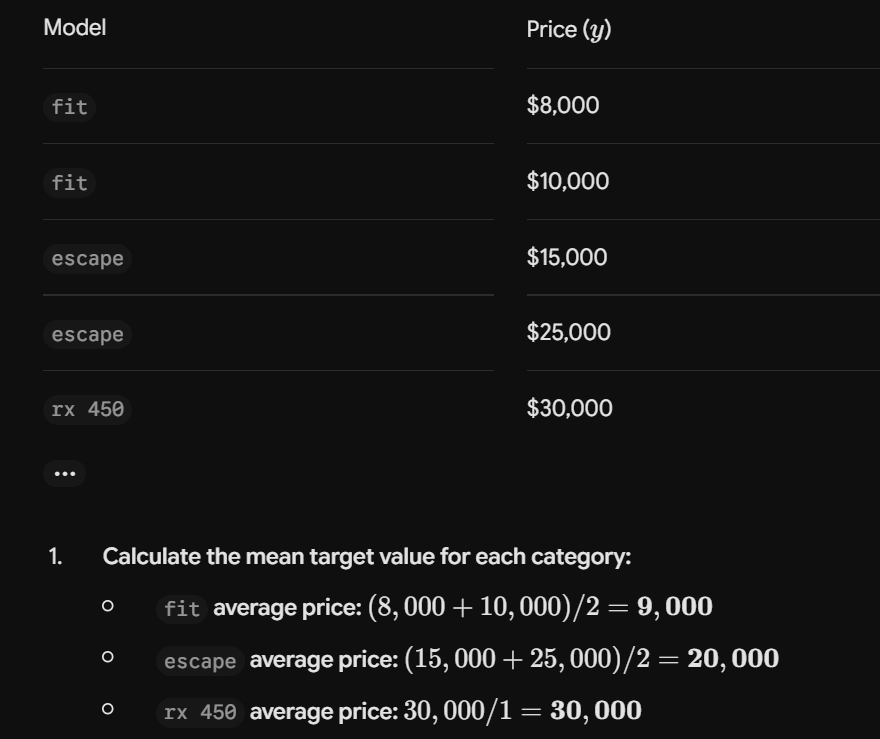

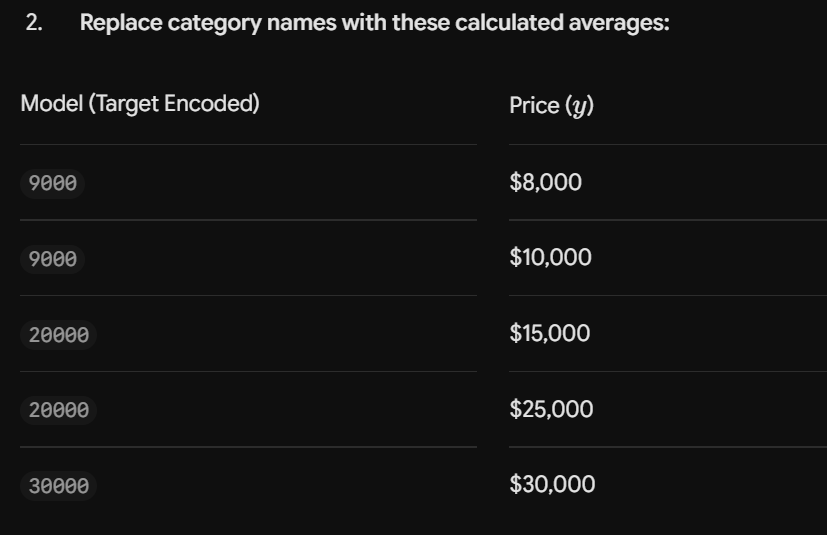

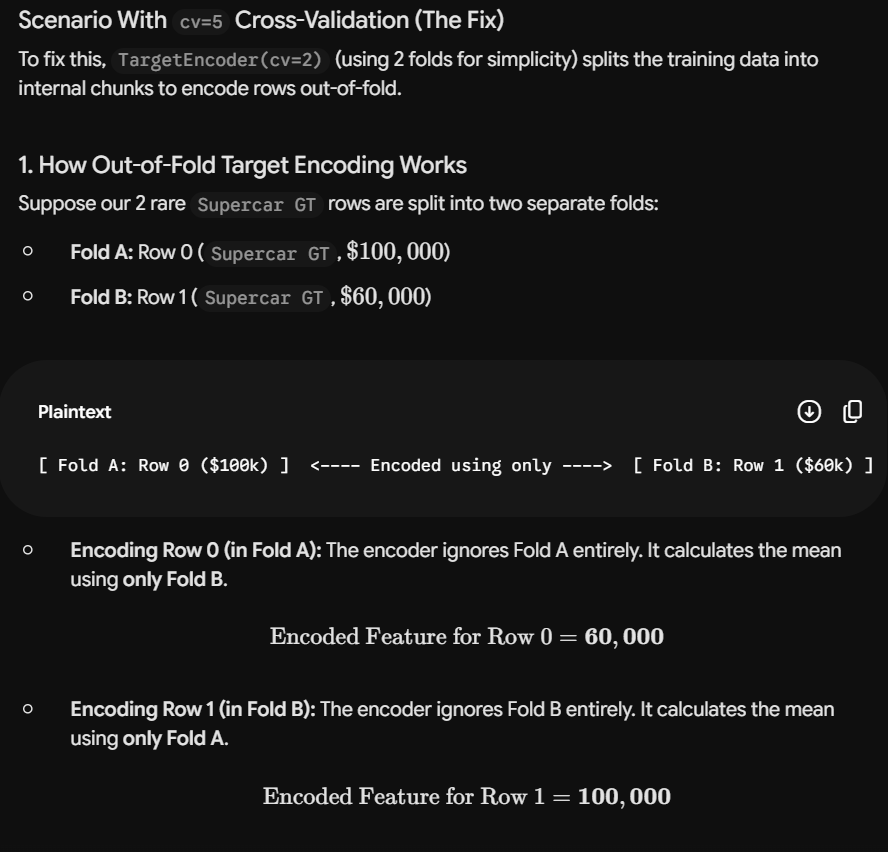

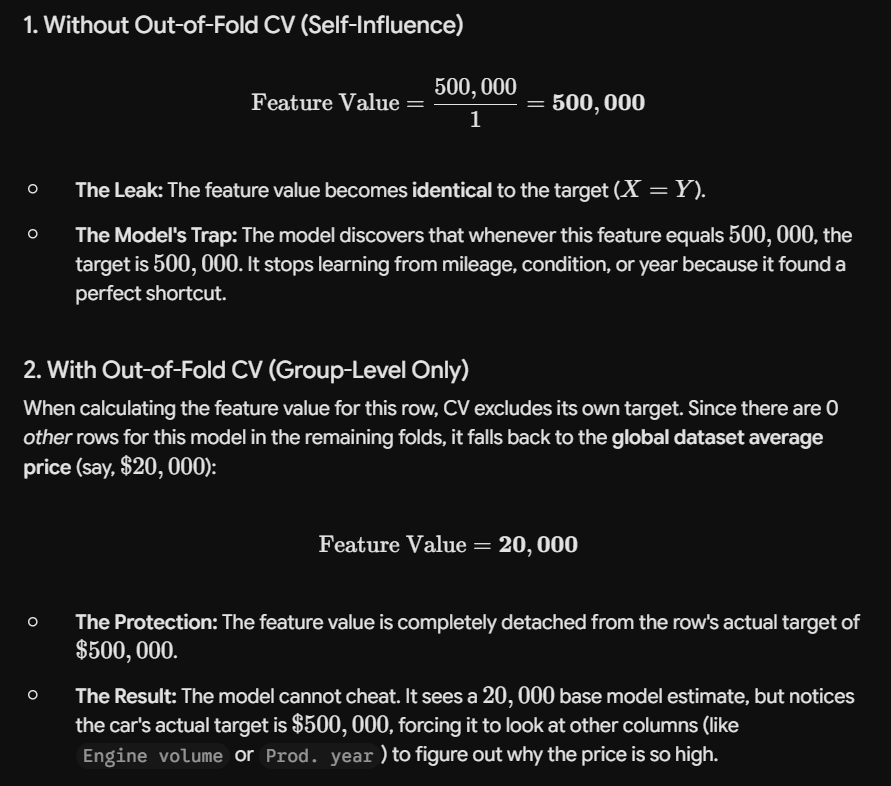

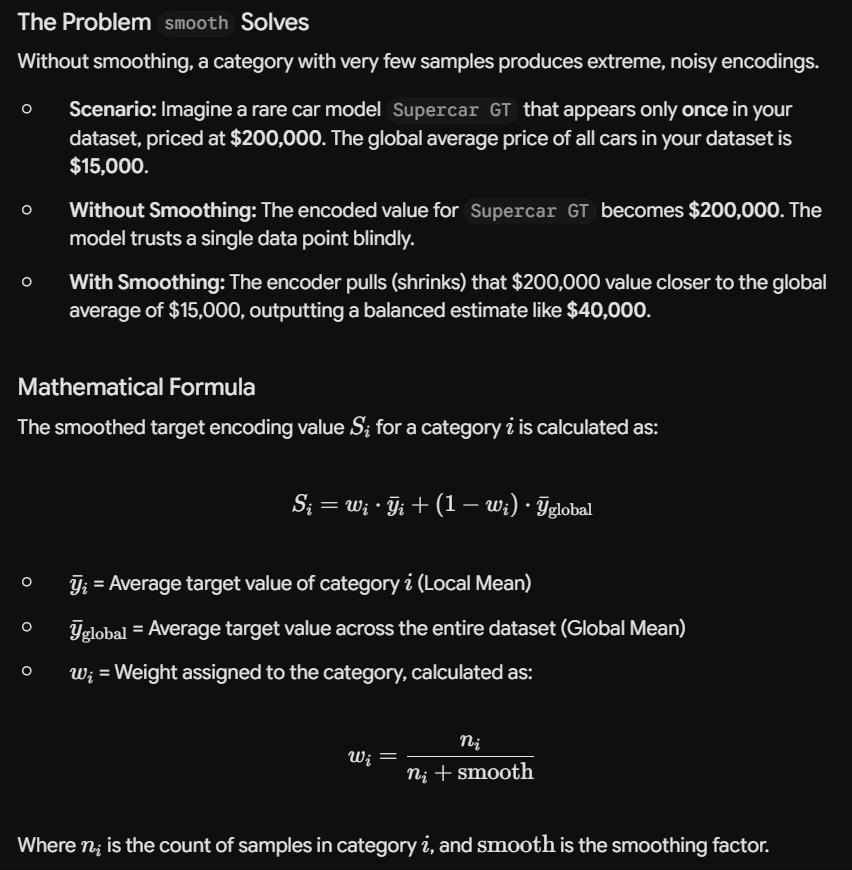

In [216]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler

X = df.drop(columns = ['Price'])
y = df['Price']

low_cardinality_cols = [col for col in X.columns if X[col].nunique() <= 20 and X[col].dtype == "object"]
high_cardinality_cols = [col for col in X.columns if X[col].nunique() > 20 and X[col].dtype == "object"]
colsToScale = X.select_dtypes(include = 'number').columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

preprocessor = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), low_cardinality_cols),
        ('te', TargetEncoder(smooth = 'auto', cv = 5, target_type = 'continuous'), high_cardinality_cols),
        ('ss', StandardScaler(), colsToScale)
    ],
    remainder = 'passthrough'
)

#Instead of apply(lambda x: log10(x)), use np.log1p() and np.expm1(). log1p calculates $\log(1 + x)$, which safely handles zero-value prices without throwing division-by-zero errors (-inf).
y_train_logscaled = np.log1p(y_train)

In [217]:
X_train_encoded = preprocessor.fit_transform(X_train, y_train_logscaled)
X_test_encoded = preprocessor.transform(X_test)

In [218]:
X_train_encoded.shape, X_test_encoded.shape

((13155, 49), (3289, 49))

In [219]:
X_test_encoded

array([[ 0.        ,  0.        ,  0.        , ...,  1.07474132,
        -0.47170431, -0.42328166],
       [ 0.        ,  0.        ,  0.        , ...,  0.12526448,
         1.36498956,  1.70597421],
       [ 0.        ,  0.        ,  0.        , ..., -1.07299097,
        -0.47170431, -0.42328166],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.28221417,
        -0.47170431, -0.42328166],
       [ 0.        ,  0.        ,  0.        , ..., -0.58653367,
        -0.47170431,  1.17366025],
       [ 0.        ,  0.        ,  0.        , ...,  0.29031912,
        -0.47170431,  0.10903231]])

In [220]:
from sklearn.metrics import r2_score, root_mean_squared_error

def model_performance1(model, X_test, y_test):
  model.fit(X_train_encoded, y_train_logscaled)
  y_pred = model.predict(X_test_encoded)
  y_pred = np.expm1(y_pred)
  print(f"R2 Score1: {r2_score(y_test, y_pred)}")
  print(f"RMSE1: {root_mean_squared_error(y_test, y_pred)}")

def model_performance2(model, X_test, y_test):
  model.fit(X_train_encoded, y_train_logscaled)
  y_pred_log = model.predict(X_test_encoded)
  y_test_log = np.log1p(y_test)
  print(f"R2 Score2: {r2_score(y_test_log, y_pred_log)}")
  print(f"RMSE2: {root_mean_squared_error(y_test_log, y_pred_log)}")

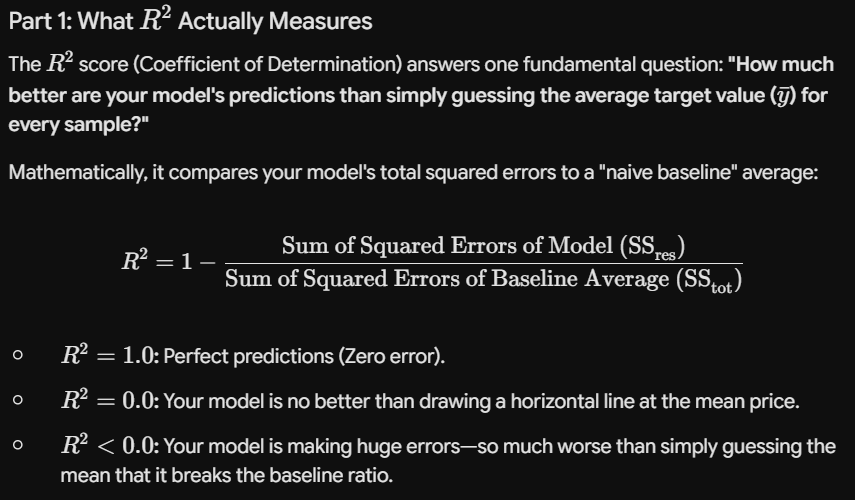

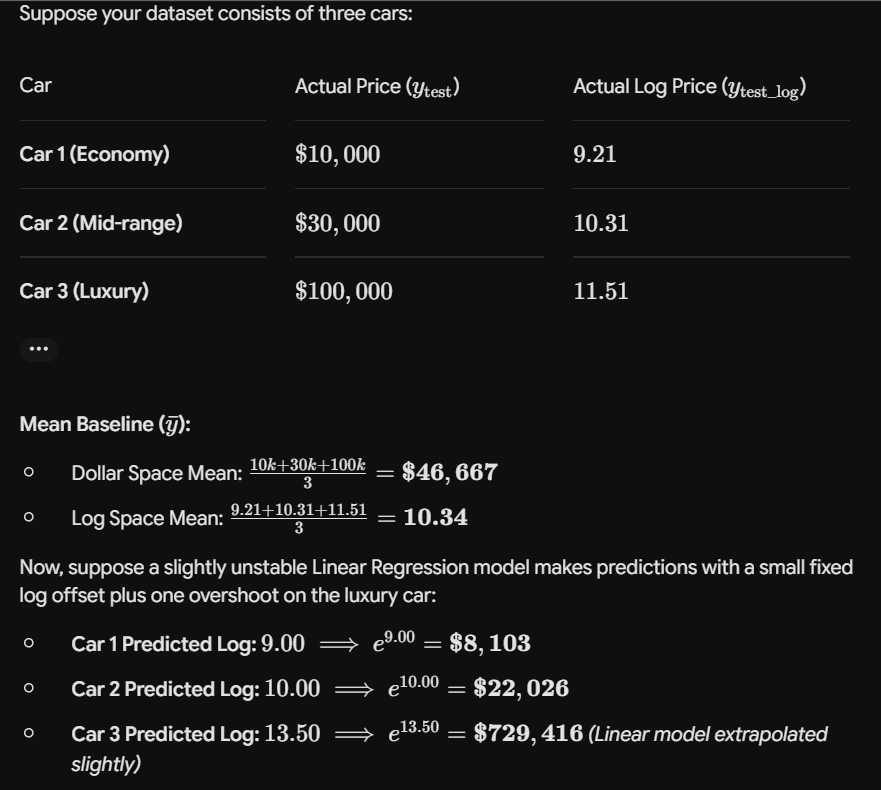

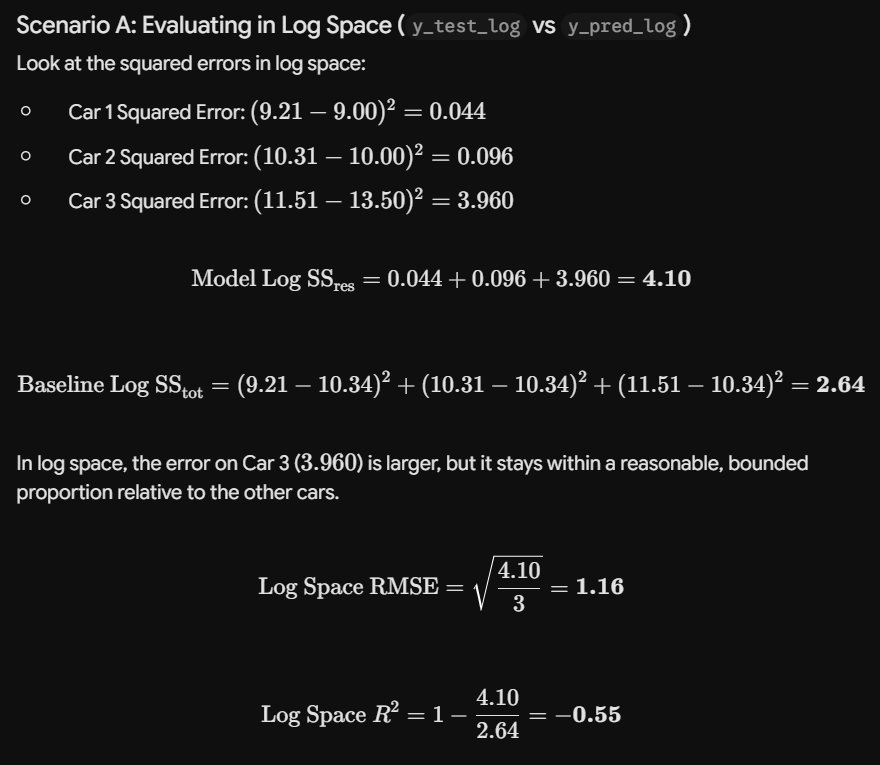

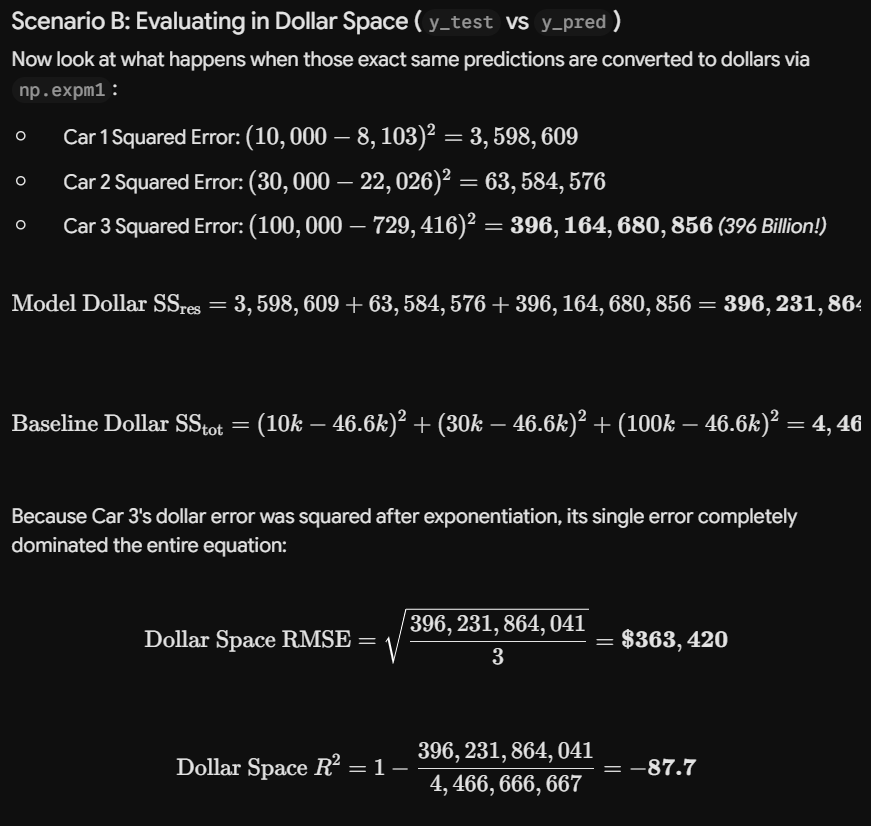

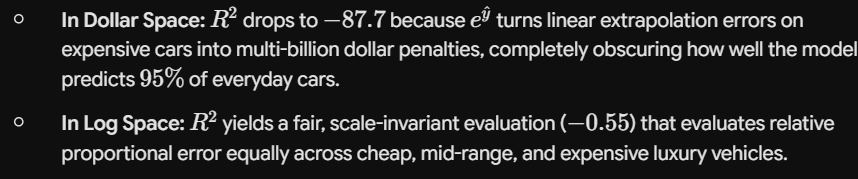

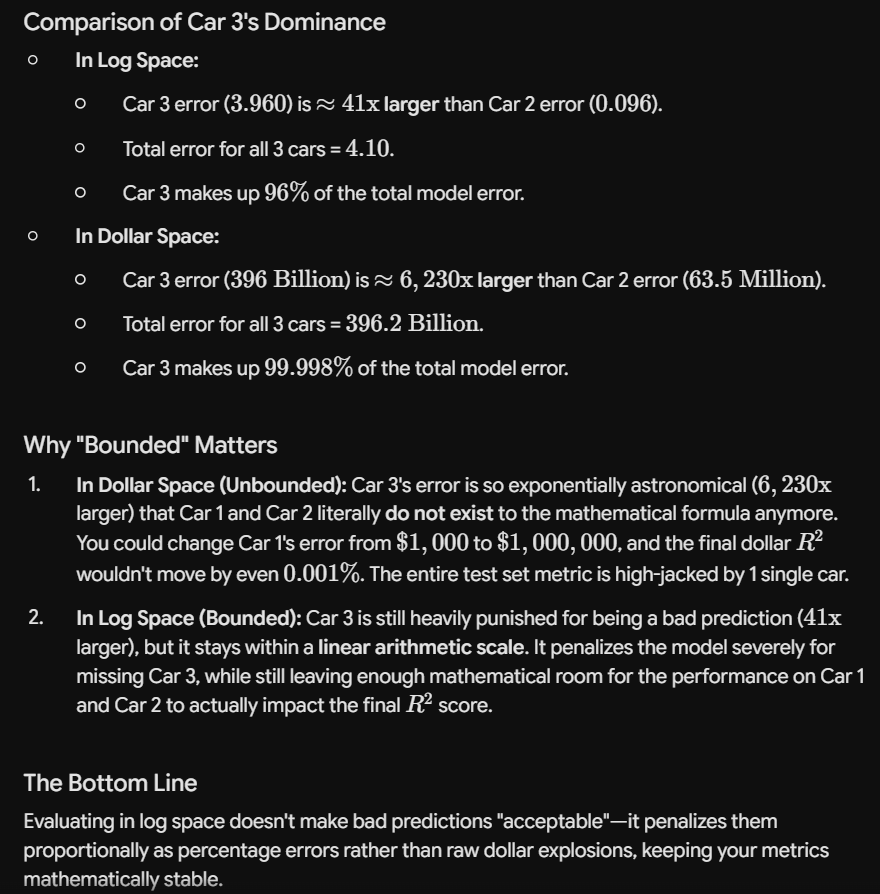

In [221]:
from sklearn.linear_model import LinearRegression

model_performance1(LinearRegression(), X_test_encoded, y_test)
print()
model_performance2(LinearRegression(), X_test_encoded, y_test)

R2 Score1: 0.43392121130297934
RMSE1: 13870.68315691479

R2 Score2: 0.44683356863996027
RMSE2: 0.6633448957547474


In [222]:
from sklearn.linear_model import Ridge

model_performance1(Ridge(), X_test_encoded, y_test)
print()
model_performance2(Ridge(), X_test_encoded, y_test)

R2 Score1: 0.43388192265896575
RMSE1: 13871.164495279923

R2 Score2: 0.4467647403716368
RMSE2: 0.663386163136272


In [223]:
from sklearn.ensemble import RandomForestRegressor

model_performance1(RandomForestRegressor(n_estimators=100, random_state=42), X_test_encoded, y_test)
print()
model_performance2(RandomForestRegressor(n_estimators=100, random_state=42), X_test_encoded, y_test)

R2 Score1: 0.6396353495015066
RMSE1: 11067.015083863958

R2 Score2: 0.7509789648970185
RMSE2: 0.44507120773199943


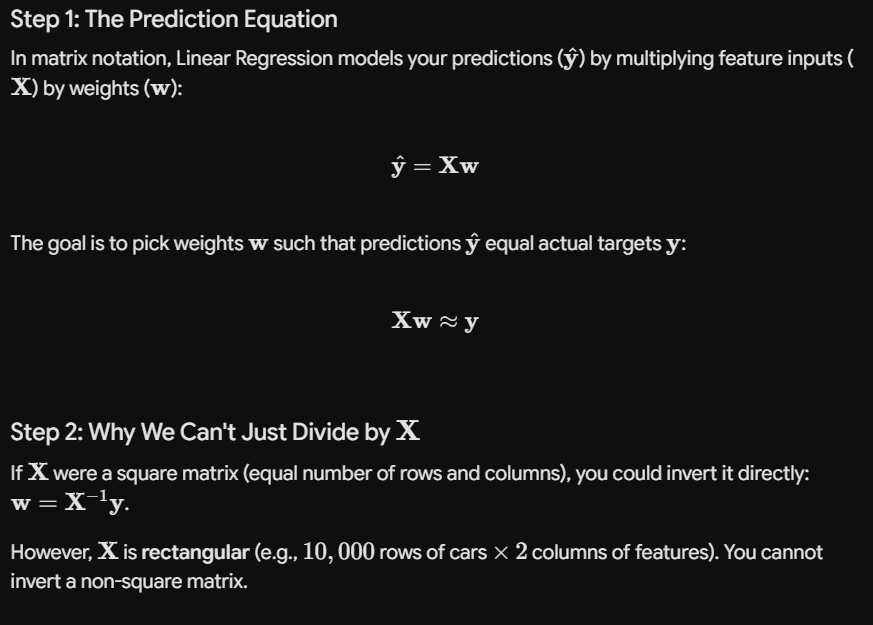

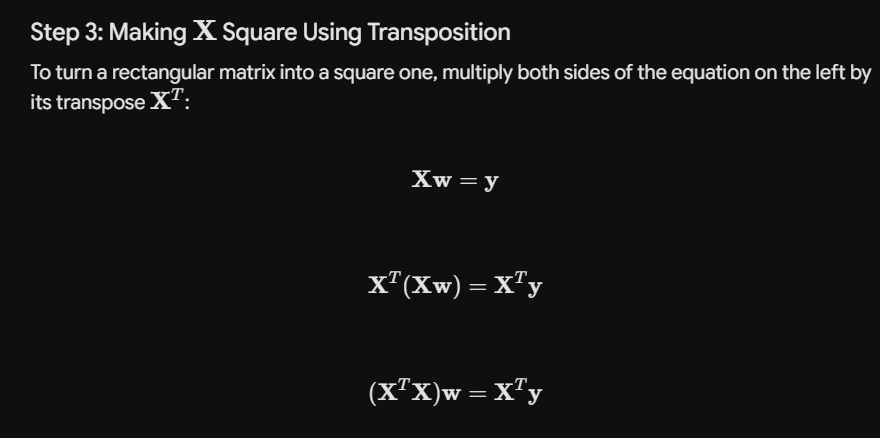

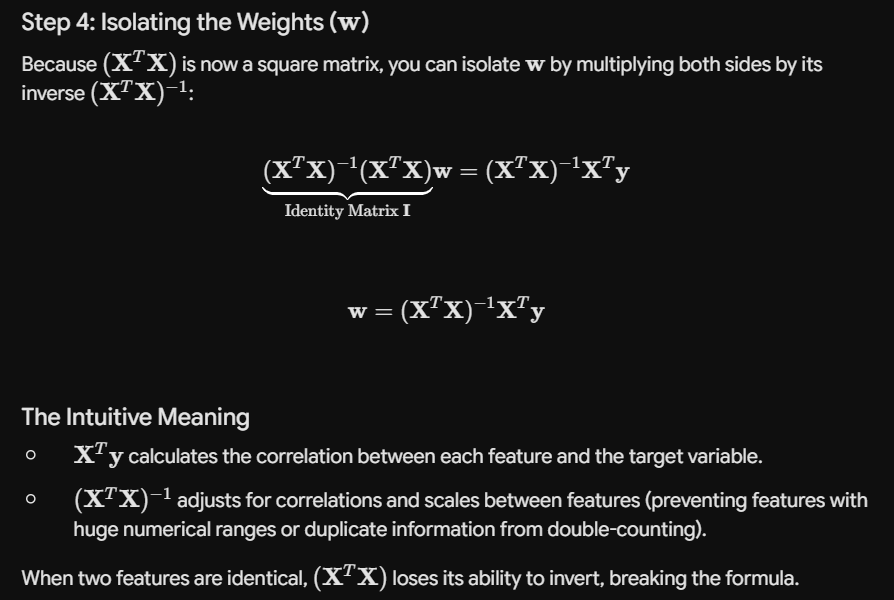

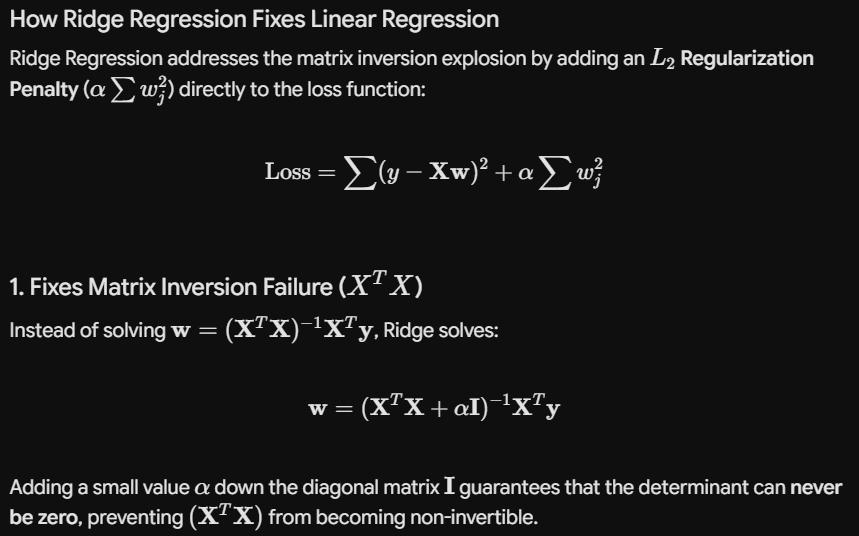



Cross Validation:

In [224]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error

X = df.drop(columns=['Price'])
y = df['Price']
y_log = np.log1p(df['Price'])

def evaluate_model_cv(evaluation_model, X, y_log, cv_folds=5):
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', evaluation_model)
    ])

    scoring = {'r2_score': 'r2', 'rmse': make_scorer(root_mean_squared_error, greater_is_better=False)}
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_result = cross_validate(full_pipeline, X, y_log, cv=kf, scoring=scoring)

    r2_scores = cv_result['test_r2_score']
    rmse_scores = -cv_result['test_rmse']

    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)

    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)

    print(f"R2 Scores: {r2_scores}")
    print(f"RMSE Scores: {rmse_scores}")
    print(f"Mean R2: {mean_r2:.4f}, Std R2: {std_r2:.4f}")
    print(f"Mean RMSE: {mean_rmse:.4f}, Std RMSE: {std_rmse:.4f}")


In [225]:
from sklearn.linear_model import LinearRegression

evaluate_model_cv(LinearRegression(), X, y_log)

R2 Scores: [0.44667644 0.45367575 0.45715359 0.44111992 0.42945512]
RMSE Scores: [0.6634391  0.62569892 0.6451586  0.66232868 0.65446594]
Mean R2: 0.4456, Std R2: 0.0098
Mean RMSE: 0.6502, Std RMSE: 0.0139


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [226]:
from sklearn.linear_model import Ridge

evaluate_model_cv(Ridge(), X, y_log)

R2 Scores: [0.44676007 0.45355009 0.45690118 0.44150833 0.42936783]
RMSE Scores: [0.66338896 0.62577088 0.64530857 0.66209849 0.65451601]
Mean R2: 0.4456, Std R2: 0.0097
Mean RMSE: 0.6502, Std RMSE: 0.0138


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [227]:
from sklearn.ensemble import RandomForestRegressor

evaluate_model_cv(RandomForestRegressor(), X, y_log)

R2 Scores: [0.75646844 0.76236087 0.75402484 0.76180876 0.75101268]
RMSE Scores: [0.44013824 0.41266643 0.4342838  0.43239149 0.43234532]
Mean R2: 0.7571, Std R2: 0.0044
Mean RMSE: 0.4304, Std RMSE: 0.0093


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [228]:
from sklearn.ensemble import RandomForestRegressor

evaluate_model_cv(RandomForestRegressor(max_depth = 10, min_samples_split=10), X, y_log)

R2 Scores: [0.64701346 0.65870084 0.65679259 0.67196534 0.64586888]
RMSE Scores: [0.5298959  0.49454724 0.51298697 0.50742763 0.5156134 ]
Mean R2: 0.6561, Std R2: 0.0094
Mean RMSE: 0.5121, Std RMSE: 0.0115


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [229]:
from sklearn.ensemble import RandomForestRegressor

evaluate_model_cv(RandomForestRegressor(max_depth = 100, min_samples_split=10), X, y_log)

R2 Scores: [0.74539926 0.7505609  0.74679093 0.75856226 0.73747566]
RMSE Scores: [0.45002984 0.42278779 0.44062348 0.43532822 0.44394272]
Mean R2: 0.7478, Std R2: 0.0069
Mean RMSE: 0.4385, Std RMSE: 0.0092


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Using GridSearchCV to perform hyper parameter tuning on RandomForestRegressor

In [230]:
from sklearn.model_selection import  GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline

kf = KFold(n_splits = 5, shuffle = True, random_state=42)

full_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator = full_pipeline,
    param_grid = params,
    cv = kf,
    scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'},
    refit = 'r2',
    n_jobs = -1,
    verbose = 1
)

random_search = RandomizedSearchCV(
    estimator = full_pipeline,
    param_distributions = params,
    n_iter = 15,
    cv = kf,
    scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'},
    refit = 'r2',
    n_jobs = -1,
    verbose = 1
)



random_search.fit(X, y_log)

print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best CV R2 Score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Hyperparameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV R2 Score: 0.7699


In [231]:
evaluate_model_cv(RandomForestRegressor(n_estimators = 300, max_depth = 30, min_samples_split=2, min_samples_leaf=1, max_features = 'sqrt'), X, y_log)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


R2 Scores: [0.76293076 0.78171111 0.76326888 0.77133399 0.76074696]
RMSE Scores: [0.43425926 0.39550865 0.42604521 0.42365765 0.42380968]
Mean R2: 0.7680, Std R2: 0.0077
Mean RMSE: 0.4207, Std RMSE: 0.0132


Add new insightful features for further model performance tweaks

In [232]:
from datetime import datetime

df['Car age'] = datetime.now().year - df['Prod. year']
df['Mileage per year'] = df['Mileage'] / (df['Car age'] + 1)
df.drop(columns = ['Prod. year'])
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Engine volume_type,Car age,Mileage per year
0,13328,1399,lexus,rx 450,2010,jeep,yes,hybrid,3.5,186005.0,6,automatic,4x4,04-may,left wheel,silver,0,normal,16,10941.470588
1,16621,1018,chevrolet,equinox,2011,jeep,no,petrol,3.0,192000.0,6,tiptronic,4x4,04-may,left wheel,black,8,normal,15,12000.000000
2,8467,0,honda,fit,2006,hatchback,no,petrol,1.3,200000.0,4,variator,front,04-may,right-hand drive,black,2,normal,20,9523.809524
3,3607,862,ford,escape,2011,jeep,yes,hybrid,2.5,168966.0,4,automatic,4x4,04-may,left wheel,white,0,normal,15,10560.375000
4,11726,446,honda,fit,2014,hatchback,yes,petrol,1.3,91901.0,4,automatic,front,04-may,left wheel,silver,4,normal,12,7069.307692
